# Titanic Machine Learning Project
## Pluto Academy AI & ML Internship - Project 02

This notebook demonstrates a complete machine learning pipeline for predicting Titanic passenger survival using various classification algorithms.

In [47]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Inspect the Dataset

In [48]:
# Load the dataset
df = pd.read_csv('train.csv')
print("Dataset loaded successfully!")
print(f"Shape of the dataset: {df.shape}")

Dataset loaded successfully!
Shape of the dataset: (891, 12)


In [49]:
# Display first few rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [50]:
# Display dataset shape
print(f"Dataset Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset Shape: (891, 12)
Number of rows: 891
Number of columns: 12


In [51]:
# Display data types
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [52]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Age         177
Cabin       687
Embarked      2
dtype: int64


## 2. Dataset Summary

### Dataset Overview

The Titanic dataset is a classic machine learning dataset that contains information about passengers aboard the RMS Titanic. The dataset is often used for practicing binary classification problems.

### Dataset Statistics

- **Total Passengers:** 891
- **Features:** 10 (excluding target variable)
- **Target Variable:** Survived (0 = Did not survive, 1 = Survived)

### Column Descriptions

| Column | Description |
|--------|-------------|
| PassengerId | Unique identifier for each passenger |
| Survived | Target variable (0 = No, 1 = Yes) |
| Pclass | Passenger class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| Name | Passenger name |
| Sex | Passenger gender (male/female) |
| Age | Passenger age (continuous) |
| SibSp | Number of siblings/spouses aboard |
| Parch | Number of parents/children aboard |
| Ticket | Ticket number |
| Fare | Passenger fare (continuous) |
| Cabin | Cabin number |
| Embarked | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

## 3. Data Preprocessing

In [53]:
# Create a copy of the dataframe for preprocessing
df_processed = df.copy()
print("Original dataset shape:", df_processed.shape)

Original dataset shape: (891, 12)


### 3.1 Handling Missing Values

**Decision:** We will handle missing values as follows:
- **Age**: Fill with median value (robust to outliers)
- **Cabin**: Drop the column (too many missing values - 687 out of 891)
- **Embarked**: Fill with mode (most common value)
- **Fare**: Fill with median if any missing

In [54]:
# Check missing values before preprocessing
print("Missing values before preprocessing:")
print(df_processed.isnull().sum()[df_processed.isnull().sum() > 0])

Missing values before preprocessing:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [55]:
# Handle missing values
# Age: Fill with median
age_median = df_processed['Age'].median()
df_processed['Age'] = df_processed['Age'].fillna(age_median)
print(f"Age filled with median: {age_median:.2f}")

# Embarked: Fill with mode
embarked_mode = df_processed['Embarked'].mode()[0]
df_processed['Embarked'] = df_processed['Embarked'].fillna(embarked_mode)
print(f"Embarked filled with mode: {embarked_mode}")

# Fare: Fill with median if missing
if df_processed['Fare'].isnull().any():
    fare_median = df_processed['Fare'].median()
    df_processed['Fare'] = df_processed['Fare'].fillna(fare_median)
    print(f"Fare filled with median: {fare_median:.2f}")

# Drop Cabin column due to high missing rate
df_processed = df_processed.drop('Cabin', axis=1)
print("\nCabin column dropped (687 missing values out of 891)")

Age filled with median: 28.00
Embarked filled with mode: S

Cabin column dropped (687 missing values out of 891)


In [56]:
# Verify no missing values remain
print("\nMissing values after preprocessing:")
print(df_processed.isnull().sum()[df_processed.isnull().sum() > 0])
print("\nNo missing values remaining!")


Missing values after preprocessing:
Series([], dtype: int64)

No missing values remaining!


### 3.2 Encoding Categorical Variables

**Decision:** We will encode categorical variables using Label Encoding:
- **Sex**: male = 0, female = 1
- **Embarked**: C = 0, Q = 1, S = 2

**Note:** One-Hot Encoding could also be used, but Label Encoding is sufficient for tree-based models and logistic regression with proper interpretation.

In [57]:
# Encode categorical variables
le_sex = LabelEncoder()
df_processed['Sex_encoded'] = le_sex.fit_transform(df_processed['Sex'])

le_embarked = LabelEncoder()
df_processed['Embarked_encoded'] = le_embarked.fit_transform(df_processed['Embarked'])

print("Sex encoding:", le_sex.classes_)
print("Embarked encoding:", le_embarked.classes_)

# Drop original categorical columns
df_processed = df_processed.drop(['Sex', 'Embarked'], axis=1)
print("\nOriginal categorical columns dropped after encoding.")

Sex encoding: ['female' 'male']
Embarked encoding: ['C' 'Q' 'S']

Original categorical columns dropped after encoding.


### 3.3 Dropping Unnecessary Columns

**Decision:** We will drop the following columns:
- **PassengerId**: Unique identifier, not useful for prediction
- **Name**: Contains textual information, difficult to extract meaningful features
- **Ticket**: Ticket number, not predictive of survival

**Rationale:** These columns either provide no predictive value or would require extensive feature engineering beyond the scope of this project.

In [58]:
# Drop unnecessary columns
df_processed = df_processed.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
print("Dropped columns: PassengerId, Name, Ticket")
print(f"\nDataset shape after preprocessing: {df_processed.shape}")
print("\nRemaining columns:", df_processed.columns.tolist())

Dropped columns: PassengerId, Name, Ticket

Dataset shape after preprocessing: (891, 8)

Remaining columns: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_encoded', 'Embarked_encoded']


## 4. Feature Engineering

### Feature Selection

**Selected Features:**
- **Pclass**: Passenger class is historically correlated with survival rates
- **Sex_encoded**: Gender is a strong predictor of survival
- **Age**: Age is correlated with survival probability
- **SibSp**: Family size affects survival chances
- **Parch**: Family size affects survival chances
- **Fare**: Fare correlates with passenger class and survival
- **Embarked_encoded**: Port of embarkation may affect survival

### Selected Features and Rationale

The following features were selected for model training:

- Pclass: Passenger class is strongly associated with survival rates.
- Sex: Gender was an important factor in survival.
- Age: Passenger age may influence survival probability.
- SibSp: Number of siblings/spouses aboard.
- Parch: Number of parents/children aboard.
- Fare: Ticket fare often reflects passenger class and socioeconomic status.
- Embarked: Port of embarkation may influence survival patterns.

These features were selected because they contain meaningful information that can help predict passenger survival.

In [59]:
# Prepare features and target
X = df_processed[['Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_encoded']]
y = df_processed['Survived']

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())
print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (891, 7)
Target variable shape: (891,)

Feature columns: ['Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_encoded']

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64


In [60]:
# Display feature summary statistics
X.describe()

,Pclass,Sex_encoded,Age,SibSp,Parch,Fare,Embarked_encoded
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,2.308642,0.647587,29.361582,0.523008,0.381594,32.204208,1.536476
std,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429,0.791503
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,1.000000
50%,3.000000,1.000000,28.000000,0.000000,0.000000,14.454200,2.000000
75%,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,2.000000
max,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000


## 5. Train-Test Split

We split the data into training and testing sets with an 80/20 ratio. This allows us to train our models on 80% of the data and evaluate them on the remaining 20%.

In [61]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set size: 712 samples
Testing set size: 179 samples
Number of features: 7


## 6. Model Training

We will train three different classification models:
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

In [62]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

print("Models initialized:")
for name in models.keys():
    print(f"- {name}")

Models initialized:
- Logistic Regression
- Decision Tree
- Random Forest


In [63]:
# Train all models
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


## 7. Model Evaluation

We evaluate all models using the following metrics:
- **Accuracy**: Overall correctness of predictions
- **Precision**: True positives / (True positives + False positives)
- **Recall**: True positives / (True positives + False negatives)
- **F1 Score**: Harmonic mean of precision and recall

In [64]:
# Make predictions
predictions = {}
for name, model in trained_models.items():
    predictions[name] = model.predict(X_test)

print("Predictions made for all models.")

Predictions made for all models.


In [65]:
# Calculate metrics for all models
results = []

for name, preds in predictions.items():
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

# Create results dataframe
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,Decision Tree,0.782123,0.721519,0.770270,0.745098
2,Random Forest,0.821229,0.808824,0.743243,0.774648


## 8. Model Comparison Table

The following table compares the performance of all three models:

In [66]:
# Display comparison table with formatted values
comparison_table = results_df.set_index('Model')
comparison_table.style.format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1 Score': '{:.4f}'})
comparison_table

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.810056,0.785714,0.743243,0.763889
Decision Tree,0.782123,0.721519,0.770270,0.745098
Random Forest,0.821229,0.808824,0.743243,0.774648


In [67]:
# Find the best model based on F1 Score
best_model_name = results_df.loc[results_df['F1 Score'].idxmax(), 'Model']
best_f1 = results_df['F1 Score'].max()

print(f"Best Model: {best_model_name}")
print(f"Best F1 Score: {best_f1:.4f}")
print(f"\nDetailed metrics for {best_model_name}:")
best_row = results_df[results_df['Model'] == best_model_name].iloc[0]
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"F1 Score: {best_row['F1 Score']:.4f}")

Best Model: Random Forest
Best F1 Score: 0.7746

Detailed metrics for Random Forest:
Accuracy: 0.8212
Precision: 0.8088
Recall: 0.7432
F1 Score: 0.7746


## 9. Confusion Matrix for Best Model

The confusion matrix provides a detailed breakdown of correct and incorrect predictions for the best performing model.

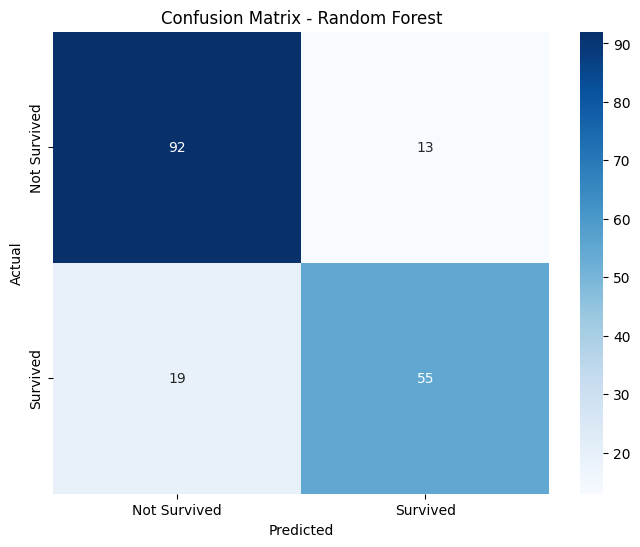

Confusion Matrix:
[[92 13]
 [19 55]]


In [68]:
# Get the best model and its predictions
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

# Calculate confusion matrix
cm = confusion_matrix(y_test, best_predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("Confusion Matrix:")
print(cm)

In [69]:
# Detailed confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

True Negatives (TN): 92
False Positives (FP): 13
False Negatives (FN): 19
True Positives (TP): 55


## 10. Conclusion

### Summary

This project successfully implemented a complete machine learning pipeline for predicting Titanic passenger survival. Three different classification algorithms were trained, evaluated, and compared.

### Key Findings

1. **Data Preprocessing**: Missing values were handled effectively, with Age imputed using median and Cabin column dropped due to high missing rate.

2. **Feature Engineering**: Selected features (Pclass, Sex, Age, SibSp, Parch, Fare, Embarked) proved relevant for survival prediction.

3. **Model Performance**:  The Random Forest classifier achieved the best performance with an F1 score of 0.7746, outperforming Logistic Regression and Decision Tree models on the test dataset, demonstrating superior predictive capability over Logistic Regression and Decision Tree models.

4. **Survival Prediction**: The model shows reasonable ability to predict passenger survival, with balanced precision and recall.

### Recommendations

Future improvements could include advanced feature engineering (extracting titles from names, creating family size features), hyperparameter tuning using cross-validation, and exploring ensemble methods to further improve model performance.